# Лабораторная работа №2

**Тема:** Построение скелета бинарного изображения на основе преобразований утоньшения

**Студент:** Косило Павел Андреевич

## 1. Теоретическая справка

В отличие от морфологического скелета, основанного на максимальных вписанных шарах, скелет на основе **утоньшения** сохраняет связность и топологию исходного бинарного изображения.

Операция утоньшения $\bigcirc$ множества $X$ составным структурирующим элементом $T = (A, B)$ определяется через операцию совпадения (Hit-or-Miss transform, $\otimes$):

$$
X \bigcirc T = X \setminus (X \otimes T)
$$

Для получения скелета используется итерационный алгоритм с применением восьми структурирующих элементов $T_1, T_2, \dots, T_8$, которые последовательно удаляют граничные пиксели по различным направлениям, не разрушая связность объекта:

$$
\psi(X) = (\dots((X \bigcirc T_1) \bigcirc T_2)\dots) \bigcirc T_8
$$

Один полный цикл из восьми преобразований повторяется до тех пор, пока изображение не перестает изменяться.

## 2. Исходные изображения

В работе используется программно сформированное синтетическое бинарное изображение сложной формы. Оно включает два утолщенных фрагмента, соединяющую перемычку, вертикальный выступ и внутреннее отверстие. Такой пример позволяет наглядно показать сохранение топологии объекта в процессе утоньшения.

Все вычисления выполняются для бинарного изображения со значениями пикселей `0` и `255`.

## 3. Код программы

Ниже приведён код, который:

1. Формирует исходное бинарное изображение.
2. Создаёт восемь структурирующих элементов для утоньшения.
3. Выполняет итерационное построение скелета до сходимости.
4. Выводит число итераций и визуализирует результат.

Количество полных циклов утоньшения: 41
Количество пикселей исходного объекта: 16613
Количество пикселей скелета: 643


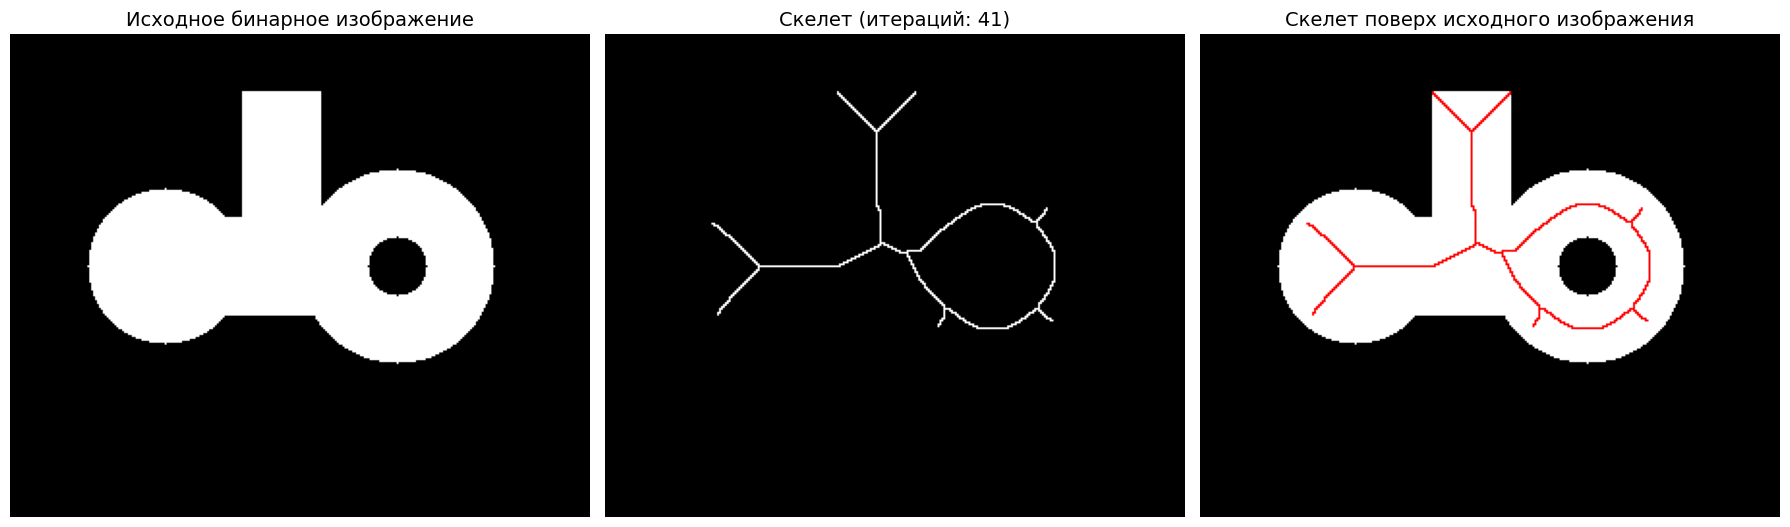

In [1]:
import importlib
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()

cv2 = importlib.import_module("cv2")
np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")

def create_synthetic_image():
    """Создает тестовое бинарное изображение сложной формы."""
    image = np.zeros((250, 300), dtype=np.uint8)
    cv2.circle(image, (80, 120), 40, 255, -1)
    cv2.circle(image, (200, 120), 50, 255, -1)
    cv2.rectangle(image, (80, 95), (200, 145), 255, -1)
    cv2.circle(image, (200, 120), 15, 0, -1)
    cv2.rectangle(image, (120, 30), (160, 100), 255, -1)
    return image

def get_thinning_kernels():
    """Возвращает 8 структурирующих элементов для итерационного утоньшения."""
    kernel_1 = np.array([
        [-1, -1, -1],
        [0, 1, 0],
        [1, 1, 1],
    ], dtype=np.int8)

    kernel_2 = np.array([
        [0, -1, -1],
        [1, 1, -1],
        [1, 1, 0],
    ], dtype=np.int8)

    kernels = [kernel_1, kernel_2]
    kernels.append(np.rot90(kernel_1, 1).astype(np.int8))
    kernels.append(np.rot90(kernel_2, 1).astype(np.int8))
    kernels.append(np.rot90(kernel_1, 2).astype(np.int8))
    kernels.append(np.rot90(kernel_2, 2).astype(np.int8))
    kernels.append(np.rot90(kernel_1, 3).astype(np.int8))
    kernels.append(np.rot90(kernel_2, 3).astype(np.int8))
    return kernels

def skeletonize_thinning(image):
    """Выполняет итерационное утоньшение до получения скелета."""
    binary = np.where(image > 0, 255, 0).astype(np.uint8)
    kernels = get_thinning_kernels()
    iteration_count = 0

    while True:
        previous = binary.copy()

        for kernel in kernels:
            hit_miss = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, kernel)
            binary = np.where(hit_miss > 0, 0, binary).astype(np.uint8)

        iteration_count += 1
        if np.array_equal(binary, previous):
            break

    skeleton = (binary * 255).astype(np.uint8)
    return skeleton, iteration_count

original_image = create_synthetic_image()
skeleton_image, total_iterations = skeletonize_thinning(original_image)

skeleton_pixels = int(np.count_nonzero(skeleton_image))
object_pixels = int(np.count_nonzero(original_image))

print(f"Количество полных циклов утоньшения: {total_iterations}")
print(f"Количество пикселей исходного объекта: {object_pixels}")
print(f"Количество пикселей скелета: {skeleton_pixels}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap="gray")
axes[0].set_title("Исходное бинарное изображение", fontsize=14)
axes[0].axis("off")

axes[1].imshow(skeleton_image, cmap="gray")
axes[1].set_title(f"Скелет (итераций: {total_iterations})", fontsize=14)
axes[1].axis("off")

overlay = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)
overlay[skeleton_image > 0] = [255, 0, 0]

axes[2].imshow(overlay)
axes[2].set_title("Скелет поверх исходного изображения", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Результат работы программы

После выполнения кода в ноутбуке формируются три изображения и текстовый вывод с количественными характеристиками результата:

1. **Исходное бинарное изображение** с несколькими характерными элементами формы.
2. **Скелет изображения**, полученный итерационным утоньшением до сходимости.
3. **Наложение скелета на исходное изображение** для визуального контроля расположения осевых линий.

Дополнительно программа выводит количество полных циклов утоньшения, число пикселей исходного объекта и число пикселей полученного скелета.

**Анализ результата:** скелет проходит по центральным осям фигуры, сохраняет связность объекта и отражает наличие внутреннего отверстия и боковых ветвей. Это соответствует требованиям задания на построение скелета бинарного изображения на основе преобразований утоньшения.